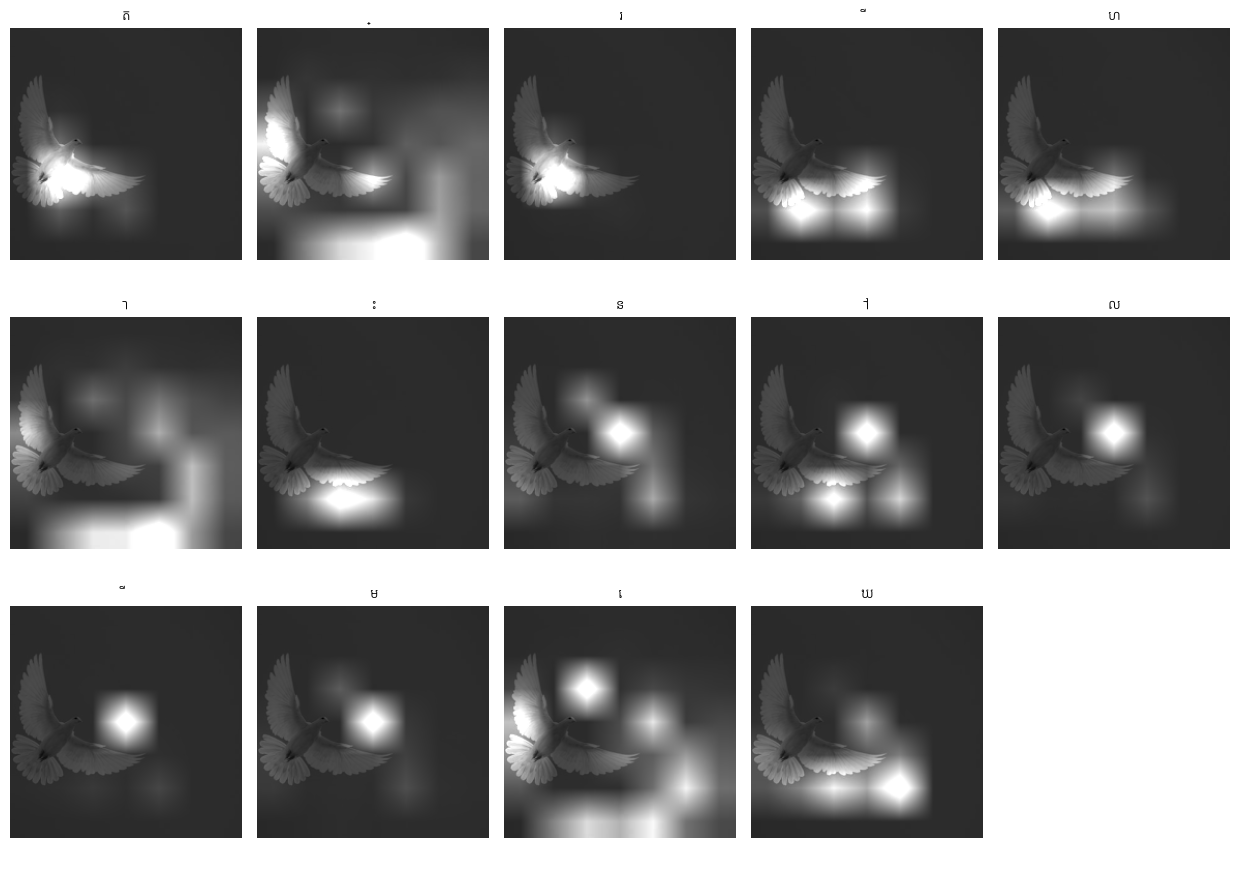

Generated Caption: ត្រីហោះនៅលើមេឃ


In [41]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2
from matplotlib import font_manager as fm
import math

# Function to load idx2word and convert it to word2idx
def load_vocabulary(path):
    with open(path, 'r') as file:
        idx2word = json.load(file)
    word2idx = {v: int(k) for k, v in idx2word.items()}
    return idx2word, word2idx

# Load vocabulary
idx2word_path = '/home/vitoupro/code/image_captioning/notebook/idx2word.json'
idx2word, word2idx = load_vocabulary(idx2word_path)

# Attention module
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.attn = nn.Linear(encoder_dim + decoder_dim, attention_dim)
        self.v = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, hidden):
        hidden = hidden.unsqueeze(1).repeat(1, encoder_out.size(1), 1)
        attn_input = torch.cat((encoder_out, hidden), dim=2)
        energy = torch.tanh(self.attn(attn_input))
        attention = self.v(energy).squeeze(2)
        alpha = torch.softmax(attention, dim=1)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha

# Encoder
class EncoderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(pretrained=True)
        for name, param in resnet.named_parameters():
            param.requires_grad = 'layer4' in name
        self.resnet = nn.Sequential(*list(resnet.children())[:-2])

    def forward(self, images):
        features = self.resnet(images)
        features = features.permute(0, 2, 3, 1)
        features = features.view(features.size(0), -1, features.size(-1))
        return features

# Decoder
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, attention_dim=256, encoder_dim=2048):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(encoder_dim, hidden_size, attention_dim)
        self.lstm = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)
        self.dropout = nn.Dropout(0.3)

    def forward_step(self, encoder_out, last_token, h, c):
        embedded = self.dropout(self.embed(last_token))
        context, _ = self.attention(encoder_out, h)
        lstm_input = torch.cat([embedded, context], dim=1)
        h, c = self.lstm(lstm_input, (h, c))
        output = self.linear(h)
        return output, h, c

def create_soft_spotlight(img_tensor, attention_map):
    """Create a soft spotlight overlay using gray-to-white gradient"""
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    
    # Resize attention map to match image dimensions
    attention_resized = cv2.resize(attention_map, (img.shape[1], img.shape[0]))
    
    # Normalize attention to 0-1 range
    attention_norm = (attention_resized - attention_resized.min()) / (attention_resized.max() - attention_resized.min() + 1e-8)
    
    # Create spotlight effect: gray background with white highlights
    # Convert to grayscale first
    img_gray = np.dot(img, [0.299, 0.587, 0.114])
    img_gray = np.stack([img_gray] * 3, axis=-1)  # Convert back to 3-channel
    
    # Create spotlight mask: 0.3 (dark gray) to 1.0 (white)
    spotlight_intensity = 0.3 + 2* attention_norm
    spotlight_mask = np.stack([spotlight_intensity] * 3, axis=-1)
    
    # Apply spotlight effect
    spotlighted_img = img_gray * spotlight_mask
    
    return np.clip(spotlighted_img, 0, 1)

# Model & device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder = EncoderCNN().to(device)
decoder = DecoderRNN(embed_size=256, hidden_size=512, vocab_size=len(word2idx)).to(device)
encoder.load_state_dict(torch.load('encoder_final_defense.pth'))
decoder.load_state_dict(torch.load('decoder_final_defense.pth'))
encoder.eval()
decoder.eval()

# Generate caption using beam search and visualize attention with soft spotlight
def generate_caption_with_spotlight(image_path, beam_size=5):
    image = Image.open(image_path).convert("RGB")
    tensor_img = transform(image).unsqueeze(0).to(device)
    img_for_display = transform(image).to(device)
    encoder_out = encoder(tensor_img)

    k = beam_size
    vocab_size = len(word2idx)

    seqs = torch.LongTensor([[word2idx['<START>']]] * k).to(device)
    scores = torch.zeros(k, 1).to(device)
    complete_seqs, complete_scores, complete_spotlights = [], [], []
    h = decoder.init_h(encoder_out.mean(dim=1).expand(k, -1))
    c = decoder.init_c(encoder_out.mean(dim=1).expand(k, -1))
    encoder_out = encoder_out.expand(k, -1, -1)
    spotlight_list = [[] for _ in range(k)]

    for _ in range(40):
        last_words = seqs[:, -1]
        outputs, h, c = decoder.forward_step(encoder_out, last_words, h, c)
        log_probs = torch.log_softmax(outputs, dim=1)
        scores_expanded = scores + log_probs
        scores_topk, topk_indices = scores_expanded.view(-1).topk(k, dim=0)

        prev_beam_indices = topk_indices // vocab_size
        next_word_indices = topk_indices % vocab_size

        seqs = torch.cat([seqs[prev_beam_indices], next_word_indices.unsqueeze(1)], dim=1)
        scores = scores_topk.unsqueeze(1)
        h = h[prev_beam_indices]
        c = c[prev_beam_indices]
        encoder_out = encoder_out[prev_beam_indices]

        # Generate attention spotlight for top candidate
        with torch.no_grad():
            _, alpha = decoder.attention(encoder_out, h)  # (k, 196)
            attention_map = alpha[0].view(7, 7).cpu().numpy()
            spotlight_img = create_soft_spotlight(img_for_display, attention_map)
            spotlight_list[0].append(spotlight_img)

        incomplete_inds = [i for i, next_word in enumerate(next_word_indices) if next_word != word2idx['<END>']]
        complete_inds = list(set(range(len(next_word_indices))) - set(incomplete_inds))

        if len(complete_inds) > 0:
            complete_seqs.extend(seqs[complete_inds].tolist())
            complete_scores.extend(scores[complete_inds])
            complete_spotlights.extend([spotlight_list[i] for i in complete_inds])
        k -= len(complete_inds)

        if k == 0:
            break

        seqs = seqs[incomplete_inds]
        scores = scores[incomplete_inds]
        h = h[incomplete_inds]
        c = c[incomplete_inds]
        encoder_out = encoder_out[incomplete_inds]
        spotlight_list = [spotlight_list[i] for i in incomplete_inds]

    best_seq_idx = complete_scores.index(max(complete_scores))
    best_seq = complete_seqs[best_seq_idx]
    best_spotlights = complete_spotlights[best_seq_idx]

    tokens = [idx2word[str(idx)] for idx in best_seq if idx not in [word2idx['<START>'], word2idx['<END>'], word2idx['<PAD>']]]

    khmer_font_path = "/home/vitoupro/code/image_captioning/data/KantumruyPro-VariableFont_wght.ttf"
    khmer_font = fm.FontProperties(fname=khmer_font_path)

    tokens_per_row = 5
    num_rows = math.ceil(len(tokens) / tokens_per_row)
    fig, axes = plt.subplots(num_rows, tokens_per_row, figsize=(tokens_per_row * 2.5, num_rows * 3))

    if num_rows == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i in range(num_rows * tokens_per_row):
        ax = axes[i]
        if i < len(tokens):
            ax.imshow(best_spotlights[i])
            ax.set_title(tokens[i], fontsize=300, fontproperties=khmer_font)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return ''.join(tokens)

# Image path and transform
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])
image_path = '/home/vitoupro/code/image_captioning/notebook/image.png'
# Run
caption = generate_caption_with_spotlight(image_path)
print("Generated Caption:", caption)


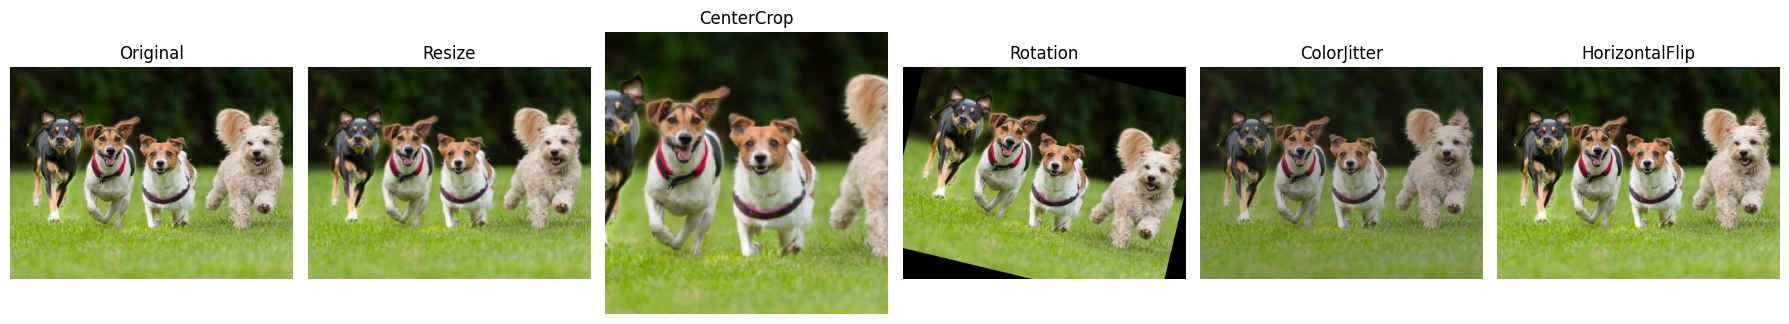

In [1]:
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import torchvision.transforms.functional as TF
import random
import torch

# Load the original image
img_path = '/home/vitoupro/code/image_captioning/data/7.png'
original_img = Image.open(img_path).convert("RGB")

# Prepare individual transforms
resize = transforms.Resize(256)
center_crop = transforms.CenterCrop(224)
random_rotation = lambda img: TF.rotate(img, angle=random.uniform(-15, 15))
color_jitter = transforms.ColorJitter(brightness=0.2, contrast=0.2)
horizontal_flip = lambda img: TF.hflip(img) if random.random() > 0.5 else img

# Apply each transform to a copy of the image
images = [
    ("Original", original_img),
    ("Resize", resize(original_img)),
    ("CenterCrop", center_crop(resize(original_img))),
    ("Rotation", random_rotation(original_img)),
    ("ColorJitter", color_jitter(original_img)),
    ("HorizontalFlip", horizontal_flip(original_img)),
]

# Plot all images
plt.figure(figsize=(18, 4))
for i, (name, img) in enumerate(images):
    plt.subplot(1, len(images), i + 1)
    # Convert to numpy array if it's a tensor
    if isinstance(img, torch.Tensor):
        img = TF.to_pil_image(img)
    plt.imshow(img)
    plt.axis('off')
    plt.title(name)

plt.tight_layout()
plt.show()


In [2]:
import pandas as pd

# Load your annotations file
annotations_file = '/home/vitoupro/code/image_captioning/notebook/finaldata.txt'

# Read the lines and extract caption lengths
lengths = []
with open(annotations_file, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split(maxsplit=1)
        if len(parts) == 2:
            _, caption = parts
            lengths.append(len(caption))  # Count characters in the caption

# Compute statistics
min_len = min(lengths)
max_len = max(lengths)
avg_len = sum(lengths) / len(lengths)

print(f"📏 Shortest caption length : {min_len} characters")
print(f"📏 Longest caption length  : {max_len} characters")
print(f"📏 Average caption length  : {avg_len:.2f} characters")


📏 Shortest caption length : 6 characters
📏 Longest caption length  : 43 characters
📏 Average caption length  : 21.74 characters


In [10]:
print("✅ Encoder Type:", type(encoder)) 
print("✅ Number of Parameters in Encoder:", sum(p.numel() for p in encoder.parameters()))
print("✅ Number of Trainable Parameters:", sum(p.numel() for p in encoder.parameters() if p.requires_grad))

print("✅ Decoder Type:", type(decoder))
print("✅ Number of Parameters in Decoder:", sum(p.numel() for p in decoder.parameters()))
print("✅ Number of Trainable Parameters:", sum(p.numel() for p in decoder.parameters() if p.requires_grad))


✅ Encoder Type: <class '__main__.EncoderCNN'>
✅ Number of Parameters in Encoder: 23508032
✅ Number of Trainable Parameters: 14964736
✅ Decoder Type: <class '__main__.DecoderRNN'>
✅ Number of Parameters in Decoder: 8579143
✅ Number of Trainable Parameters: 8579143


📏 Shortest caption length : 6 characters
📏 Longest caption length  : 43 characters
📏 Average caption length  : 21.74 characters


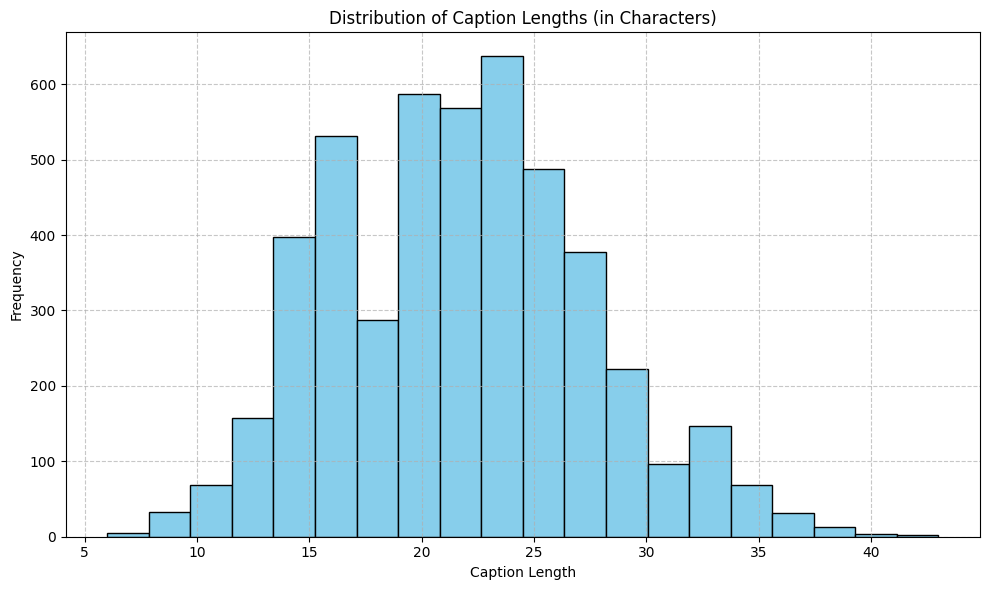

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your annotations file
annotations_file = '/home/vitoupro/code/image_captioning/notebook/finaldata.txt'

# Read the lines and extract caption lengths
lengths = []
with open(annotations_file, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split(maxsplit=1)
        if len(parts) == 2:
            _, caption = parts
            lengths.append(len(caption))  # Count characters in the caption

# Compute statistics
min_len = min(lengths)
max_len = max(lengths)
avg_len = sum(lengths) / len(lengths)

print(f"📏 Shortest caption length : {min_len} characters")
print(f"📏 Longest caption length  : {max_len} characters")
print(f"📏 Average caption length  : {avg_len:.2f} characters")

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Caption Lengths (in Characters)')
plt.xlabel('Caption Length')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
